# Programming for AI — NumPy for AI
## Complete 3-Hour Laboratory Notebook

**Student Name:** Haroon Atif  
**Course:** Programming for AI  
**Lab:** NumPy for AI  
**Level:** Undergraduate  
**Environment:** Python + NumPy + Jupyter Notebook  

### Notebook purpose
This notebook completes the full lab from **Part A through Part F**, including:
- setup and NumPy basics,
- array manipulation,
- statistics and random data,
- vectorization and basic ML calculations,
- the mini AI pipeline,
- short-answer review questions.

All major code cells are executed so their outputs are saved in the notebook.

> **Important note about Kaggle**
>
> The provided lab manual does **not** specify a Kaggle dataset, Kaggle URL, dataset slug, CSV file, or file path.  
> Instead, it provides all required data directly as NumPy arrays and explicitly asks for NumPy-based work.
>
> Therefore, the graded lab below is completed entirely with the supplied arrays so that the notebook runs end-to-end without missing external files.
>
> If your instructor separately gives you a Kaggle dataset later, the optional template below can be adapted by replacing `OWNER/DATASET-SLUG`.

In [1]:
# OPTIONAL KAGGLE TEMPLATE — NOT REQUIRED BY THE PROVIDED LAB MANUAL
# Keep this commented unless your instructor gives you a real Kaggle dataset slug.
#
# !pip install -q kagglehub
# import kagglehub
#
# kaggle_path = kagglehub.dataset_download("OWNER/DATASET-SLUG")
# print("Dataset downloaded to:", kaggle_path)

# Part A — Setup and NumPy Basics

## Task A1 — Verify the Installation
Import NumPy and display the installed version.

In [2]:
# Import NumPy for all numerical operations in this lab.
import numpy as np

print("NumPy version:", np.__version__)

NumPy version: 2.3.5


## Task A2 — Creating Arrays
Create the six arrays required by the lab and inspect their values.

In [3]:
# 1D array
a = np.array([10, 20, 30, 40, 50])

# 2D array
b = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

# Array filled with zeros
c = np.zeros((3, 4))

# Array filled with ones
d = np.ones((2, 5))

# Even values from 0 up to, but not including, 20
e = np.arange(0, 20, 2)

# Six equally spaced values between 0 and 1
f = np.linspace(0, 1, 6)

print("a =")
print(a)

print("\nb =")
print(b)

print("\nc =")
print(c)

print("\nd =")
print(d)

print("\ne =")
print(e)

print("\nf =")
print(f)

a =
[10 20 30 40 50]

b =
[[1 2 3]
 [4 5 6]]

c =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

d =
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]

e =
[ 0  2  4  6  8 10 12 14 16 18]

f =
[0.  0.2 0.4 0.6 0.8 1. ]


In [4]:
# Answers to the required inspection questions
print("Shape of b:", b.shape)
print("Number of elements in c:", c.size)

print("\nChanging the arange step from 2 to 3:")
print(np.arange(0, 20, 3))

Shape of b: (2, 3)
Number of elements in c: 12

Changing the arange step from 2 to 3:
[ 0  3  6  9 12 15 18]


### Task A2 — Answers
- **Shape of `b`:** `(2, 3)` because it has 2 rows and 3 columns.
- **Number of elements in `c`:** `12` because `3 × 4 = 12`.
- **`arange()` vs `linspace()`:**
  - `np.arange(start, stop, step)` is controlled by a **step size**.
  - `np.linspace(start, stop, number)` is controlled by the **number of evenly spaced values** and normally includes the endpoint.
- **Changing the step in `arange()`:** changes the gap between generated values and therefore also changes how many values are produced.

## Task A3 — Array Attributes and Data Types
Inspect shape, dimensions, size, and dtype, then compare `float64`, `int32`, and `float32`.

In [5]:
x = np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float64)

print("float64 array")
print("Shape:", x.shape)
print("Dimensions:", x.ndim)
print("Size:", x.size)
print("Data type:", x.dtype)
print("Bytes per element:", x.itemsize)

x_int32 = x.astype(np.int32)
x_float32 = x.astype(np.float32)

print("\nint32 dtype:", x_int32.dtype, "| Bytes per element:", x_int32.itemsize)
print("float32 dtype:", x_float32.dtype, "| Bytes per element:", x_float32.itemsize)

float64 array
Shape: (2, 3)
Dimensions: 2
Size: 6
Data type: float64
Bytes per element: 8

int32 dtype: int32 | Bytes per element: 4
float32 dtype: float32 | Bytes per element: 4


### Task A3 — Discussion
Data type matters for large AI datasets because it affects **memory usage, numerical precision, and computation speed**.  
For example, `float32` uses less memory per value than `float64`, while `float64` provides higher numerical precision.

# Part B — Array Manipulation and Numerical Operations

## Task B1 — Indexing and Slicing

In [6]:
data = np.array([
    [10, 20, 30, 40],
    [50, 60, 70, 80],
    [90, 100, 110, 120]
])

print("Original examples:")
print("data[0, 2] =", data[0, 2])
print("data[:, 1] =", data[:, 1])
print("data[1, :] =", data[1, :])
print("data[:2, 1:3] =")
print(data[:2, 1:3])

print("\nRequired modifications:")
print("1. Last row:", data[-1, :])
print("2. First two columns:")
print(data[:, :2])
print("3. Value 110:", data[2, 2])
print("4. 2x2 block containing 60, 70, 100, 110:")
print(data[1:3, 1:3])

Original examples:
data[0, 2] = 30
data[:, 1] = [ 20  60 100]
data[1, :] = [50 60 70 80]
data[:2, 1:3] =
[[20 30]
 [60 70]]

Required modifications:
1. Last row: [ 90 100 110 120]
2. First two columns:
[[ 10  20]
 [ 50  60]
 [ 90 100]]
3. Value 110: 110
4. 2x2 block containing 60, 70, 100, 110:
[[ 60  70]
 [100 110]]


## Task B2 — Copies vs Views

In [7]:
original = np.array([10, 20, 30, 40, 50])

# Slicing normally creates a view.
view = original[1:4]

# .copy() creates independent data.
copy_array = original[1:4].copy()

view[0] = 999
copy_array[1] = 888

print("Original:", original)
print("View:", view)
print("Copy:", copy_array)

Original: [ 10 999  30  40  50]
View: [999  30  40]
Copy: [ 20 888  40]


### Task B2 — Explanation
`view` shares the same underlying memory as `original`, so changing the view changes the original array.  
`copy_array` owns independent data, so modifying it does not affect `original`.

## Task B3 — Reshape

In [8]:
values = np.arange(1, 13)

matrix_3x4 = values.reshape(3, 4)
matrix_2x6 = values.reshape(2, 6)
matrix_4x3 = values.reshape(4, 3)

print("Original values:", values)

print("\n3 x 4:")
print(matrix_3x4)
print("Shape:", matrix_3x4.shape)

print("\n2 x 6:")
print(matrix_2x6)
print("Shape:", matrix_2x6.shape)

print("\n4 x 3:")
print(matrix_4x3)
print("Shape:", matrix_4x3.shape)

print("\nAttempting an invalid reshape:")
try:
    invalid = values.reshape(5, 3)  # 15 slots required, but only 12 values exist.
except ValueError as error:
    print("ValueError:", error)

Original values: [ 1  2  3  4  5  6  7  8  9 10 11 12]

3 x 4:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Shape: (3, 4)

2 x 6:
[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]]
Shape: (2, 6)

4 x 3:
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
Shape: (4, 3)

Attempting an invalid reshape:
ValueError: cannot reshape array of size 12 into shape (5,3)


### Task B3 — Observation
A reshape is valid only when the **total number of elements remains unchanged**.  
The array contains 12 values, so shapes such as `3×4`, `2×6`, and `4×3` work, but `5×3` does not.

## Task B4 — Broadcasting

In [9]:
scores = np.array([
    [60, 70, 80],
    [65, 75, 85],
    [70, 80, 90]
])

bonus = np.array([5, 0, 10])

new_scores = scores + bonus

print("Original scores:")
print(scores)

print("\nBonus:")
print(bonus)

print("\nScores after broadcasting:")
print(new_scores)

Original scores:
[[60 70 80]
 [65 75 85]
 [70 80 90]]

Bonus:
[ 5  0 10]

Scores after broadcasting:
[[ 65  70  90]
 [ 70  75  95]
 [ 75  80 100]]


### Task B4 — Explanation
NumPy broadcasts the 1D `bonus` array across every row of `scores`.  
The three bonus values line up with the three columns, so no explicit Python loop is needed.

## Task B5 — Ufuncs and Matrix Operations

In [10]:
x = np.array([1, 4, 9, 16])

print("Square roots:", np.sqrt(x))
print("Squares:", np.square(x))
print("Exponentials:", np.exp(np.array([0, 1, 2])))

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("\nA =")
print(A)

print("\nB =")
print(B)

print("\nElement-wise multiplication (A * B):")
print(A * B)

print("\nMatrix multiplication (A @ B):")
print(A @ B)

print("\nTranspose of A:")
print(A.T)

Square roots: [1. 2. 3. 4.]
Squares: [  1  16  81 256]
Exponentials: [1.         2.71828183 7.3890561 ]

A =
[[1 2]
 [3 4]]

B =
[[5 6]
 [7 8]]

Element-wise multiplication (A * B):
[[ 5 12]
 [21 32]]

Matrix multiplication (A @ B):
[[19 22]
 [43 50]]

Transpose of A:
[[1 3]
 [2 4]]


### Task B5 — Explanation
- `A * B` multiplies values in the **same positions**.
- `A @ B` performs **matrix multiplication**, where rows of `A` are multiplied with columns of `B` and summed.
- Therefore, the two operations solve different mathematical problems and produce different results.

# Part C — Statistics and Random Data

## Task C1 — Descriptive Statistics

In [11]:
scores = np.array([55, 62, 71, 71, 75, 80, 82, 90, 94, 98])

print("Mean:", np.mean(scores))
print("Median:", np.median(scores))
print("Minimum:", np.min(scores))
print("Maximum:", np.max(scores))
print("Standard deviation:", np.std(scores))
print("Variance:", np.var(scores))

score_range = np.max(scores) - np.min(scores)
percentiles = np.percentile(scores, [25, 50, 75])

print("Range:", score_range)
print("25th percentile:", percentiles[0])
print("50th percentile:", percentiles[1])
print("75th percentile:", percentiles[2])

Mean: 77.8
Median: 77.5
Minimum: 55
Maximum: 98
Standard deviation: 13.082813153141034
Variance: 171.16000000000003
Range: 43
25th percentile: 71.0
50th percentile: 77.5
75th percentile: 88.0


## Task C2 — Axis Operations

In [12]:
marks = np.array([
    [70, 80, 90],
    [60, 75, 85],
    [90, 95, 100]
])

print("Marks:")
print(marks)

print("\nColumn means (axis=0):", np.mean(marks, axis=0))
print("Row means (axis=1):", np.mean(marks, axis=1))
print("Overall mean:", np.mean(marks))

Marks:
[[ 70  80  90]
 [ 60  75  85]
 [ 90  95 100]]

Column means (axis=0): [73.33333333 83.33333333 91.66666667]
Row means (axis=1): [80.         73.33333333 95.        ]
Overall mean: 82.77777777777777


### Task C2 — Interpretation
- `axis=0` means NumPy works **down the rows**, producing one result for each column.
- `axis=1` means NumPy works **across the columns**, producing one result for each row.

## Task C3 — Sorting and NaN Handling

In [13]:
values = np.array([45, 12, 78, 33, 91, 27])

print("Sorted:", np.sort(values))
print("Indices that sort the array:", np.argsort(values))

data_with_nan = np.array([10, 20, np.nan, 40, 50, np.nan])

print("\nData with NaN:", data_with_nan)
print("Mean with NaN:", np.mean(data_with_nan))
print("NaN-safe mean:", np.nanmean(data_with_nan))
print("NaN-safe sum:", np.nansum(data_with_nan))

Sorted: [12 27 33 45 78 91]
Indices that sort the array: [1 5 3 0 2 4]

Data with NaN: [10. 20. nan 40. 50. nan]
Mean with NaN: nan
NaN-safe mean: 30.0
NaN-safe sum: 120.0


### Task C3 — Explanation
The ordinary mean becomes `NaN` because the array contains missing numerical values represented by `np.nan`.  
`np.nanmean()` ignores the `NaN` entries when calculating the mean, while `np.nansum()` ignores them when calculating the sum.

## Task C4 — Correlation and Random Sampling

In [14]:
hours = np.array([1, 2, 3, 4, 5, 6])
scores = np.array([52, 58, 65, 71, 78, 84])

correlation = np.corrcoef(hours, scores)

print("Correlation matrix:")
print(correlation)

# Reproducible random sample using seed 42
rng_42_a = np.random.default_rng(42)
sample = rng_42_a.normal(loc=70, scale=10, size=1000)

print("\nSample using seed 42")
print("Mean:", np.mean(sample))
print("Std:", np.std(sample))

# Same seed -> identical sequence
rng_42_b = np.random.default_rng(42)
sample_same_seed = rng_42_b.normal(loc=70, scale=10, size=1000)

# Different seed -> different sequence
rng_7 = np.random.default_rng(7)
sample_different_seed = rng_7.normal(loc=70, scale=10, size=1000)

print("\nSame seed produces identical sample:",
      np.array_equal(sample, sample_same_seed))
print("Different seed produces identical sample:",
      np.array_equal(sample, sample_different_seed))

Correlation matrix:
[[1.         0.99976514]
 [0.99976514 1.        ]]

Sample using seed 42
Mean: 69.71108449004052
Std: 9.88722355396508

Same seed produces identical sample: True
Different seed produces identical sample: False


### Task C4 — Explanation
A random seed makes random-number generation **reproducible**.  
Using the same seed allows an experiment to be repeated with the same generated values; changing the seed normally produces a different sample.

## Task C5 — Histogram Data

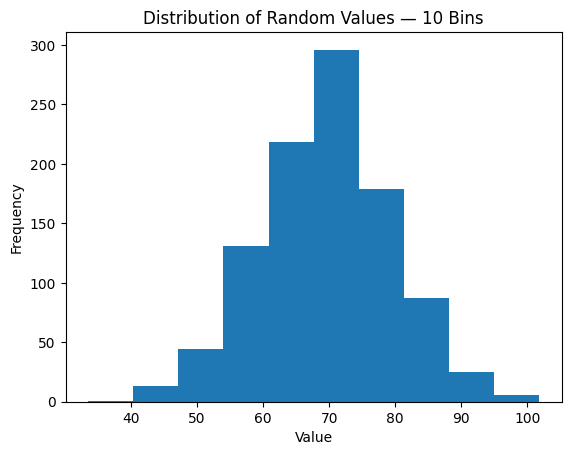

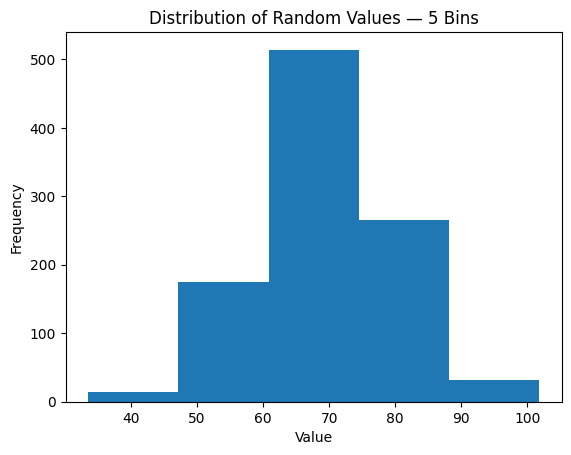

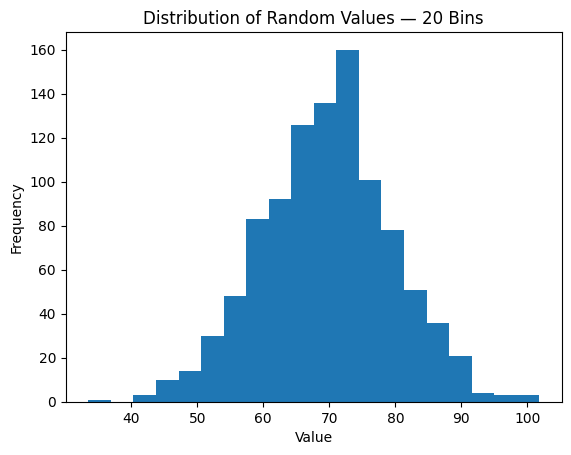

In [15]:
import matplotlib.pyplot as plt

# Plot with 10 bins
plt.figure()
plt.hist(sample, bins=10)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Random Values — 10 Bins")
plt.show()

# Plot with 5 bins
plt.figure()
plt.hist(sample, bins=5)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Random Values — 5 Bins")
plt.show()

# Plot with 20 bins
plt.figure()
plt.hist(sample, bins=20)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Random Values — 20 Bins")
plt.show()

### Task C5 — Observation
- **5 bins:** gives a simpler, more summarized view of the distribution.
- **10 bins:** gives a balanced level of detail.
- **20 bins:** shows finer variation, but the graph can look more irregular because each bin contains fewer observations.

# Part D — Vectorization and Machine-Learning Calculations

## Task D1 — Vectorization vs Python Loops

In [16]:
import time

x = np.arange(1_000_000)

loop_times = []
numpy_times = []
results_match = []

# Run the timing experiment three times because one timing is not universal.
for trial in range(1, 4):
    start = time.perf_counter()
    result_loop = [value * 2 + 5 for value in x]
    loop_time = time.perf_counter() - start

    start = time.perf_counter()
    result_numpy = x * 2 + 5
    numpy_time = time.perf_counter() - start

    loop_times.append(loop_time)
    numpy_times.append(numpy_time)
    results_match.append(np.array_equal(result_loop, result_numpy))

    print(f"Trial {trial}")
    print(f"  Python loop time: {loop_time:.6f} seconds")
    print(f"  NumPy time:       {numpy_time:.6f} seconds")
    print(f"  Results equal:    {results_match[-1]}")

print("\nAverage Python loop time:", np.mean(loop_times))
print("Average NumPy time:", np.mean(numpy_times))

Trial 1
  Python loop time: 0.118768 seconds
  NumPy time:       0.002346 seconds
  Results equal:    True
Trial 2
  Python loop time: 0.122726 seconds
  NumPy time:       0.001449 seconds
  Results equal:    True


Trial 3
  Python loop time: 0.111438 seconds
  NumPy time:       0.001575 seconds
  Results equal:    True

Average Python loop time: 0.11764393766665648
Average NumPy time: 0.0017902836666602677


### Task D1 — Interpretation
Vectorized NumPy operations usually run faster because the repeated numerical work is performed by optimized compiled routines instead of executing a Python-level loop for every element.  
Exact timing still depends on the computer and current system load.

## Task D2 — Mean Squared Error

In [17]:
actual = np.array([3, 5, 7, 9])
predicted = np.array([2.5, 5.5, 6.0, 10.0])

mse = np.mean((actual - predicted) ** 2)

# Modified predictions closer to the actual values
improved_predicted = np.array([3.0, 5.1, 6.9, 9.0])
improved_mse = np.mean((actual - improved_predicted) ** 2)

print("Original predictions:", predicted)
print("Original MSE:", mse)

print("\nImproved predictions:", improved_predicted)
print("Improved MSE:", improved_mse)
print("MSE became smaller:", improved_mse < mse)

Original predictions: [ 2.5  5.5  6.  10. ]
Original MSE: 0.625

Improved predictions: [3.  5.1 6.9 9. ]
Improved MSE: 0.0049999999999999645
MSE became smaller: True


## Task D3 — Linear Regression Prediction

In [18]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])

# Values from the lab
w = 2.0
b = 1.0

predicted = w * x + b

print("Using w = 2.0 and b = 1.0")
print("Predictions:", predicted)
print("MSE:", np.mean((y - predicted) ** 2))

# An additional experiment
w_test = 1.8
b_test = 1.2
predicted_test = w_test * x + b_test

print("\nExperiment using w = 1.8 and b = 1.2")
print("Predictions:", predicted_test)
print("MSE:", np.mean((y - predicted_test) ** 2))

Using w = 2.0 and b = 1.0
Predictions: [ 3.  5.  7.  9. 11.]
MSE: 0.0

Experiment using w = 1.8 and b = 1.2
Predictions: [ 3.   4.8  6.6  8.4 10.2]
MSE: 0.24000000000000007


### Task D3 — Observation
For this dataset, `w = 2` and `b = 1` exactly describe the relationship `y = 2x + 1`, so the MSE is zero.

## Task D4 — One Step of Gradient Descent

In [19]:
x = np.array([1., 2., 3., 4.])
y = np.array([3., 5., 7., 9.])

w = 0.0
b = 0.0
learning_rate = 0.01

# One gradient-descent update
y_pred = w * x + b

dw = (-2 / len(x)) * np.sum(x * (y - y_pred))
db = (-2 / len(x)) * np.sum(y - y_pred)

w = w - learning_rate * dw
b = b - learning_rate * db

print("After one update")
print("Updated w:", w)
print("Updated b:", b)
print("MSE:", np.mean((y - (w * x + b)) ** 2))

After one update
Updated w: 0.35000000000000003
Updated b: 0.12
MSE: 28.45315


In [20]:
# Now repeat the update for 100 iterations from the same starting point.
x = np.array([1., 2., 3., 4.])
y = np.array([3., 5., 7., 9.])

w = 0.0
b = 0.0
learning_rate = 0.01

for iteration in range(100):
    y_pred = w * x + b

    dw = (-2 / len(x)) * np.sum(x * (y - y_pred))
    db = (-2 / len(x)) * np.sum(y - y_pred)

    w = w - learning_rate * dw
    b = b - learning_rate * db

final_pred = w * x + b
final_mse = np.mean((y - final_pred) ** 2)

print("After 100 iterations")
print("Final w:", w)
print("Final b:", b)
print("Final predictions:", final_pred)
print("Final MSE:", final_mse)

After 100 iterations
Final w: 2.072226071990879
Final b: 0.7876464608565451
Final predictions: [2.85987253 4.9320986  7.00432468 9.07655075]
Final MSE: 0.007531256622522504


## Task D5 — Logistic Function

In [21]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.array([-5, -2, 0, 2, 5])
print("Original z values:", z)
print("Sigmoid outputs:", sigmoid(z))

extra_z = np.array([-10, -1, 1, 10])
print("\nAdditional z values:", extra_z)
print("Sigmoid outputs:", sigmoid(extra_z))

Original z values: [-5 -2  0  2  5]
Sigmoid outputs: [0.00669285 0.11920292 0.5        0.88079708 0.99330715]

Additional z values: [-10  -1   1  10]
Sigmoid outputs: [4.53978687e-05 2.68941421e-01 7.31058579e-01 9.99954602e-01]


### Task D5 — Observation
The sigmoid function maps real-number inputs to values between `0` and `1`.  
Large negative values approach `0`, while large positive values approach `1`.

## Task D6 — KNN Distance Calculation

In [22]:
query = np.array([2.0, 3.0])

points = np.array([
    [1.0, 2.0],
    [2.5, 3.5],
    [8.0, 9.0],
    [2.0, 4.0],
    [7.0, 8.0]
])

distances = np.sqrt(np.sum((points - query) ** 2, axis=1))
nearest_index = np.argmin(distances)

print("Query:", query)
print("Distances:", distances)
print("Nearest index:", nearest_index)
print("Nearest point:", points[nearest_index])

# Change the query point as requested
new_query = np.array([7.5, 8.5])
new_distances = np.sqrt(np.sum((points - new_query) ** 2, axis=1))
new_nearest_index = np.argmin(new_distances)

print("\nNew query:", new_query)
print("New distances:", new_distances)
print("New nearest index:", new_nearest_index)
print("New nearest point:", points[new_nearest_index])

Query: [2. 3.]
Distances: [1.41421356 0.70710678 8.48528137 1.         7.07106781]
Nearest index: 1
Nearest point: [2.5 3.5]

New query: [7.5 8.5]
New distances: [9.19238816 7.07106781 0.70710678 7.1063352  0.70710678]
New nearest index: 2
New nearest point: [8. 9.]


## Task D7 — PCA-Style Centering and Covariance

In [23]:
X = np.array([
    [2.0, 1.0],
    [3.0, 2.0],
    [4.0, 3.0],
    [5.0, 4.0],
    [6.0, 5.0]
])

feature_means = np.mean(X, axis=0)
X_centered = X - feature_means
covariance = np.cov(X_centered, rowvar=False)

print("Original data:")
print(X)

print("\nFeature means:")
print(feature_means)

print("\nCentered data:")
print(X_centered)

print("\nCentered feature means (approximately zero):")
print(np.mean(X_centered, axis=0))

print("\nCovariance matrix:")
print(covariance)

Original data:
[[2. 1.]
 [3. 2.]
 [4. 3.]
 [5. 4.]
 [6. 5.]]

Feature means:
[4. 3.]

Centered data:
[[-2. -2.]
 [-1. -1.]
 [ 0.  0.]
 [ 1.  1.]
 [ 2.  2.]]

Centered feature means (approximately zero):
[0. 0.]

Covariance matrix:
[[2.5 2.5]
 [2.5 2.5]]


### Task D7 — Explanation
Centering subtracts each feature's mean so that each centered feature has a mean near zero.  
This is important for PCA because PCA analyzes variation around the data's center rather than being influenced by the original offset of each feature.

## Task D8 — Neural Network Forward Pass

In [24]:
X = np.array([
    [1.0, 2.0],
    [2.0, 1.0]
])

W1 = np.array([
    [0.5, -0.2, 0.3],
    [0.4, 0.1, -0.5]
])

b1 = np.array([0.1, 0.2, 0.3])

# Matrix multiplication followed by bias broadcasting
hidden = X @ W1 + b1

# ReLU activation function
hidden_relu = np.maximum(0, hidden)

W2 = np.array([
    [0.2],
    [-0.4],
    [0.5]
])

b2 = np.array([0.1])

# Second matrix multiplication followed by bias broadcasting
output = hidden_relu @ W2 + b2

print("Hidden pre-activation:")
print(hidden)

print("\nHidden layer after ReLU:")
print(hidden_relu)

print("\nOutput:")
print(output)

Hidden pre-activation:
[[ 1.4  0.2 -0.4]
 [ 1.5 -0.1  0.4]]

Hidden layer after ReLU:
[[1.4 0.2 0. ]
 [1.5 0.  0.4]]

Output:
[[0.3]
 [0.6]]


### Task D8 — Where each operation is used
- **Matrix multiplication:** `X @ W1` and `hidden_relu @ W2`
- **Broadcasting:** adding `b1` and `b2`
- **Activation function:** `np.maximum(0, hidden)`, which implements ReLU

# Part E — Mini AI Pipeline Challenge

## Problem Scenario
Each row contains:
1. **Hours studied**
2. **Practice questions completed**

The target `y` is the student's score.

The pipeline below uses **NumPy only**.

In [25]:
# Student feature matrix
X = np.array([
    [1, 10],
    [2, 15],
    [3, 20],
    [4, 28],
    [5, 35],
    [6, 42],
    [7, 50],
    [8, 60]
], dtype=float)

# Student scores
y = np.array([45, 50, 55, 62, 68, 74, 81, 88], dtype=float)

print("X:")
print(X)

print("\ny:")
print(y)

X:
[[ 1. 10.]
 [ 2. 15.]
 [ 3. 20.]
 [ 4. 28.]
 [ 5. 35.]
 [ 6. 42.]
 [ 7. 50.]
 [ 8. 60.]]

y:
[45. 50. 55. 62. 68. 74. 81. 88.]


## Step 5 — Inspect `X` and `y`

In [26]:
print("X shape:", X.shape)
print("X ndim:", X.ndim)
print("X size:", X.size)
print("X dtype:", X.dtype)

print("\ny shape:", y.shape)
print("y ndim:", y.ndim)
print("y size:", y.size)
print("y dtype:", y.dtype)

X shape: (8, 2)
X ndim: 2
X size: 16
X dtype: float64

y shape: (8,)
y ndim: 1
y size: 8
y dtype: float64


## Step 6 — Feature Means and Standard Deviations

In [27]:
feature_mean = np.mean(X, axis=0)
feature_std = np.std(X, axis=0)

print("Feature means:", feature_mean)
print("Feature standard deviations:", feature_std)

Feature means: [ 4.5 32.5]
Feature standard deviations: [ 2.29128785 16.38596961]


## Step 7 — Standardize `X`

In [28]:
X_standardized = (X - feature_mean) / feature_std

print("Standardized X:")
print(X_standardized)

print("\nMean after standardization:")
print(np.mean(X_standardized, axis=0))

print("\nStd after standardization:")
print(np.std(X_standardized, axis=0))

Standardized X:
[[-1.52752523 -1.37312594]
 [-1.09108945 -1.06798685]
 [-0.65465367 -0.76284775]
 [-0.21821789 -0.27462519]
 [ 0.21821789  0.15256955]
 [ 0.65465367  0.57976429]
 [ 1.09108945  1.06798685]
 [ 1.52752523  1.67826504]]

Mean after standardization:
[ 0.00000000e+00 -2.77555756e-17]

Std after standardization:
[1. 1.]


## Step 8 — Split into Training and Testing Data with NumPy Slicing

In [29]:
# First 6 rows for training, last 2 rows for testing.
X_train = X_standardized[:6]
X_test = X_standardized[6:]

y_train = y[:6]
y_test = y[6:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train:", y_train)
print("y_test:", y_test)

X_train shape: (6, 2)
X_test shape: (2, 2)
y_train: [45. 50. 55. 62. 68. 74.]
y_test: [81. 88.]


## Steps 9–10 — Initial Linear Prediction and Test MSE

In [30]:
# Start with simple initial parameters.
weights = np.zeros(X_train.shape[1])
bias = np.mean(y_train)

initial_train_pred = X_train @ weights + bias
initial_test_pred = X_test @ weights + bias

initial_train_mse = np.mean((y_train - initial_train_pred) ** 2)
initial_test_mse = np.mean((y_test - initial_test_pred) ** 2)

print("Initial weights:", weights)
print("Initial bias:", bias)
print("Initial training predictions:", initial_train_pred)
print("Initial test predictions:", initial_test_pred)
print("Initial training MSE:", initial_train_mse)
print("Initial test MSE:", initial_test_mse)

Initial weights: [0. 0.]
Initial bias: 59.0
Initial training predictions: [59. 59. 59. 59. 59. 59.]
Initial test predictions: [59. 59.]
Initial training MSE: 101.33333333333333
Initial test MSE: 662.5


## Step 11 — Improve the Model with Gradient Descent

In [31]:
# Reset parameters before training.
weights = np.zeros(X_train.shape[1])
bias = 0.0

learning_rate = 0.05
iterations = 2000
n_train = len(y_train)

mse_history = []

for iteration in range(iterations):
    # Forward prediction
    predictions = X_train @ weights + bias

    # Prediction error
    errors = predictions - y_train

    # MSE for tracking
    mse = np.mean(errors ** 2)
    mse_history.append(mse)

    # Gradients of MSE
    dw = (2 / n_train) * (X_train.T @ errors)
    db = (2 / n_train) * np.sum(errors)

    # Parameter update
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

print("Initial recorded training MSE:", mse_history[0])
print("Final recorded training MSE:", mse_history[-1])
print("MSE decreased:", mse_history[-1] < mse_history[0])

Initial recorded training MSE: 3582.3333333333335
Final recorded training MSE: 0.0448934221487755
MSE decreased: True


## Steps 12–13 — Final Weights, Bias, Training MSE, Test MSE, and Explanation

In [32]:
final_train_pred = X_train @ weights + bias
final_test_pred = X_test @ weights + bias

final_train_mse = np.mean((y_train - final_train_pred) ** 2)
final_test_mse = np.mean((y_test - final_test_pred) ** 2)

print("Final weights:", weights)
print("Final bias:", bias)

print("\nFinal training predictions:", final_train_pred)
print("Actual training values:", y_train)
print("Final training MSE:", final_train_mse)

print("\nFinal test predictions:", final_test_pred)
print("Actual test values:", y_test)
print("Final test MSE:", final_test_mse)

Final weights: [7.9965094  6.03645549]
Final bias: 65.25255758998853

Final training predictions: [44.74887407 50.08079548 55.41271689 61.84981345 67.91851829 73.98722314]
Actual training values: [45. 50. 55. 62. 68. 74.]
Final training MSE: 0.044880981286611964

Final test predictions: [80.4243197 87.5981997]
Actual test values: [81. 88.]
Final test MSE: 0.24642564034241038


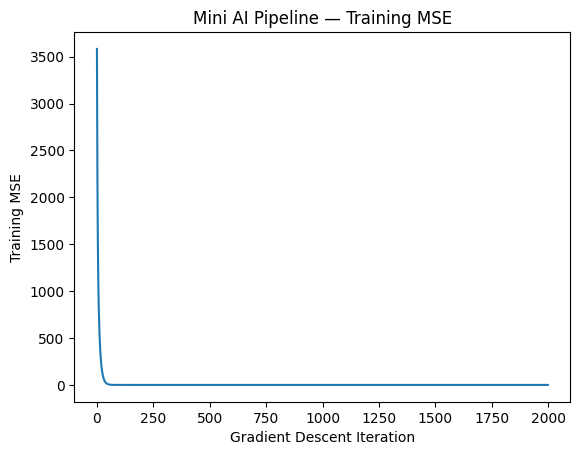

In [33]:
# Visualize the decrease in training error.
plt.figure()
plt.plot(mse_history)
plt.xlabel("Gradient Descent Iteration")
plt.ylabel("Training MSE")
plt.title("Mini AI Pipeline — Training MSE")
plt.show()

### Mini AI Pipeline — Explanation
NumPy first calculates feature statistics and standardizes the data through **vectorized subtraction, division, and axis-based operations**.  
The model then makes predictions with **matrix multiplication plus a bias**, calculates MSE, and uses vectorized gradient calculations to repeatedly update the weights and bias.  
The final MSE values show how well the learned linear model fits the training data and generalizes to the two held-out test rows.

# Part F — Review and Submission

## Short Questions — Completed Answers

### 14. What is the difference between a NumPy array's shape and size?
- **Shape** gives the length of each dimension, such as `(3, 4)`.
- **Size** gives the total number of elements, such as `12`.

### 15. What is the difference between a view and a copy?
A **view** shares underlying data with the original array, so a change can affect the original.  
A **copy** has independent data, so changing it does not alter the original.

### 16. Why is broadcasting useful in AI/data-processing code?
Broadcasting lets NumPy apply operations between compatible arrays of different shapes without writing explicit loops. This makes code shorter and enables efficient vectorized calculations.

### 17. What is the difference between element-wise multiplication (`*`) and matrix multiplication (`@`)?
- `*` multiplies corresponding array elements.
- `@` performs linear-algebra matrix multiplication using row-by-column products and summation.

### 18. What does `axis=0` mean when calculating a statistic on a 2D array?
It performs the calculation down the rows and returns one result for each column.

### 19. Why can vectorized NumPy operations be faster than Python loops?
NumPy moves much of the repeated numerical work into optimized compiled code, reducing Python-level loop overhead.

### 20. Why is `np.nanmean()` useful when a dataset contains missing numerical values?
It calculates the mean while ignoring `NaN` values, so missing entries do not automatically make the result `NaN`.

### 21. What numerical operations are shared by linear regression and a neural-network forward pass?
Both can use **weighted sums, multiplication, addition of a bias, matrix/vector operations, and prediction-error calculations**. Neural networks extend these ideas with additional layers and activation functions.